In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv("/content/starbucks.csv")

df.head()

,Beverage_category,Beverage,Beverage_prep,Calories,Total Fat (g),Trans Fat (g),Saturated Fat (g),Sodium (mg),Total Carbohydrates (g),Cholesterol (mg),Dietary Fibre (g),Sugars (g),Protein (g),Vitamin A (% DV),Vitamin C (% DV),Calcium (% DV),Iron (% DV),Caffeine (mg)
0,Coffee,Brewed Coffee,Short,3,0.1,0.0,0.0,0,5,0,0,0,0.3,0%,0%,0%,0%,175
1,Coffee,Brewed Coffee,Tall,4,0.1,0.0,0.0,0,10,0,0,0,0.5,0%,0%,0%,0%,260
2,Coffee,Brewed Coffee,Grande,5,0.1,0.0,0.0,0,10,0,0,0,1.0,0%,0%,0%,0%,330
3,Coffee,Brewed Coffee,Venti,5,0.1,0.0,0.0,0,10,0,0,0,1.0,0%,0%,2%,0%,410
4,Classic Espresso Drinks,Caffè Latte,Short Nonfat Milk,70,0.1,0.1,0.0,5,75,10,0,9,6.0,10%,0%,20%,0%,75


In [4]:
## 1. Data Understanding

##This section examines the dataset structure, dimensions, variables, and data types before proceeding with data cleaning and exploratory analysis.

In [5]:
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset Shape: (242, 18)

Columns:
['Beverage_category', 'Beverage', 'Beverage_prep', 'Calories', ' Total Fat (g)', 'Trans Fat (g) ', 'Saturated Fat (g)', ' Sodium (mg)', ' Total Carbohydrates (g) ', 'Cholesterol (mg)', ' Dietary Fibre (g)', ' Sugars (g)', ' Protein (g) ', 'Vitamin A (% DV) ', 'Vitamin C (% DV)', ' Calcium (% DV) ', 'Iron (% DV) ', 'Caffeine (mg)']


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242 entries, 0 to 241
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Beverage_category          242 non-null    object 
 1   Beverage                   242 non-null    object 
 2   Beverage_prep              242 non-null    object 
 3   Calories                   242 non-null    int64  
 4    Total Fat (g)             242 non-null    object 
 5   Trans Fat (g)              242 non-null    float64
 6   Saturated Fat (g)          242 non-null    float64
 7    Sodium (mg)               242 non-null    int64  
 8    Total Carbohydrates (g)   242 non-null    int64  
 9   Cholesterol (mg)           242 non-null    int64  
 10   Dietary Fibre (g)         242 non-null    int64  
 11   Sugars (g)                242 non-null    int64  
 12   Protein (g)               242 non-null    float64
 13  Vitamin A (% DV)           242 non-null    object 

In [7]:
df.describe()

,Calories,Trans Fat (g),Saturated Fat (g),Sodium (mg),Total Carbohydrates (g),Cholesterol (mg),Dietary Fibre (g),Sugars (g),Protein (g)
count,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000
mean,193.871901,1.307025,0.037603,6.363636,128.884298,35.991736,0.805785,32.962810,6.978512
std,102.863303,1.640259,0.071377,8.630257,82.303223,20.795186,1.445944,19.730199,4.871659
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,120.000000,0.100000,0.000000,0.000000,70.000000,21.000000,0.000000,18.000000,3.000000
50%,185.000000,0.500000,0.000000,5.000000,125.000000,34.000000,0.000000,32.000000,6.000000
75%,260.000000,2.000000,0.100000,10.000000,170.000000,50.750000,1.000000,43.750000,10.000000
max,510.000000,9.000000,0.300000,40.000000,340.000000,90.000000,8.000000,84.000000,20.000000


In [8]:
df.columns.tolist()

['Beverage_category',
 'Beverage',
 'Beverage_prep',
 'Calories',
 ' Total Fat (g)',
 'Trans Fat (g) ',
 'Saturated Fat (g)',
 ' Sodium (mg)',
 ' Total Carbohydrates (g) ',
 'Cholesterol (mg)',
 ' Dietary Fibre (g)',
 ' Sugars (g)',
 ' Protein (g) ',
 'Vitamin A (% DV) ',
 'Vitamin C (% DV)',
 ' Calcium (% DV) ',
 'Iron (% DV) ',
 'Caffeine (mg)']

In [9]:
df.columns = df.columns.str.strip()

df.columns.tolist()

['Beverage_category',
 'Beverage',
 'Beverage_prep',
 'Calories',
 'Total Fat (g)',
 'Trans Fat (g)',
 'Saturated Fat (g)',
 'Sodium (mg)',
 'Total Carbohydrates (g)',
 'Cholesterol (mg)',
 'Dietary Fibre (g)',
 'Sugars (g)',
 'Protein (g)',
 'Vitamin A (% DV)',
 'Vitamin C (% DV)',
 'Calcium (% DV)',
 'Iron (% DV)',
 'Caffeine (mg)']

In [10]:
df.isnull().sum()

,0
Beverage_category,0
Beverage,0
Beverage_prep,0
Calories,0
Total Fat (g),0
Trans Fat (g),0
Saturated Fat (g),0
Sodium (mg),0
Total Carbohydrates (g),0
Cholesterol (mg),0


In [11]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [12]:
df.dtypes

,0
Beverage_category,object
Beverage,object
Beverage_prep,object
Calories,int64
Total Fat (g),object
Trans Fat (g),float64
Saturated Fat (g),float64
Sodium (mg),int64
Total Carbohydrates (g),int64
Cholesterol (mg),int64


In [13]:
columns_to_check = [
    'Total Fat (g)',
    'Vitamin A (% DV)',
    'Vitamin C (% DV)',
    'Calcium (% DV)',
    'Iron (% DV)',
    'Caffeine (mg)'
]

for col in columns_to_check:
    print(f"\n--- {col} ---")
    print(df[col].unique()[:20])


--- Total Fat (g) ---
['0.1' '3.5' '2.5' '0.2' '6' '4.5' '0.3' '7' '5' '0.4' '9' '1.5' '4' '2'
 '8' '3' '11' '0' '1' '10']

--- Vitamin A (% DV) ---
['0%' '10%' '6%' '15%' '20%' '30%' '25%' '8%' '4%' '2%' '50%']

--- Vitamin C (% DV) ---
['0%' '2%' '4%' '6%' '10%' '15%' '20%' '80%' '100%' '8%']

--- Calcium (% DV) ---
['0%' '2%' '20%' '30%' '40%' '50%' '15%' '25%' '35%' '45%' '10%' '60%'
 '6%' '8%']

--- Iron (% DV) ---
['0%' '8%' '15%' '25%' '10%' '20%' '30%' '40%' '50%' '6%' '2%' '4%'
 '0.00%' '6.00%' '8.00%' '10.00%' '15.00%' '35%']

--- Caffeine (mg) ---
['175' '260' '330' '410' '75' '150' '85' '95' '180' '225' '300' '10' '20'
 '25' '30' '0' 'Varies' '50' '70' '120']


In [14]:
# Convert Total Fat to numeric
df['Total Fat (g)'] = pd.to_numeric(df['Total Fat (g)'], errors='coerce')

# Remove % sign and convert vitamin/mineral columns to numeric
percentage_columns = [
    'Vitamin A (% DV)',
    'Vitamin C (% DV)',
    'Calcium (% DV)',
    'Iron (% DV)'
]

for col in percentage_columns:
    df[col] = (
        df[col]
        .str.replace('%', '', regex=False)
        .astype(float)
    )

# Replace non-numeric caffeine value with NaN and convert to numeric
df['Caffeine (mg)'] = pd.to_numeric(
    df['Caffeine (mg)'],
    errors='coerce'
)

df.dtypes

,0
Beverage_category,object
Beverage,object
Beverage_prep,object
Calories,int64
Total Fat (g),float64
Trans Fat (g),float64
Saturated Fat (g),float64
Sodium (mg),int64
Total Carbohydrates (g),int64
Cholesterol (mg),int64


In [15]:
df[df['Caffeine (mg)'].isnull()][
    ['Beverage_category', 'Beverage', 'Beverage_prep', 'Caffeine (mg)']
]

,Beverage_category,Beverage,Beverage_prep,Caffeine (mg)
102,Tazo® Tea Drinks,Tazo® Tea,Short,NaN
103,Tazo® Tea Drinks,Tazo® Tea,Tall,NaN
104,Tazo® Tea Drinks,Tazo® Tea,Grande,NaN
105,Tazo® Tea Drinks,Tazo® Tea,Venti,NaN
130,Tazo® Tea Drinks,Tazo® Full-Leaf Tea Latte,Short Nonfat Milk,NaN
131,Tazo® Tea Drinks,Tazo® Full-Leaf Tea Latte,2% Milk,NaN
132,Tazo® Tea Drinks,Tazo® Full-Leaf Tea Latte,Soymilk,NaN
133,Tazo® Tea Drinks,Tazo® Full-Leaf Tea Latte,Tall Nonfat Milk,NaN
134,Tazo® Tea Drinks,Tazo® Full-Leaf Tea Latte,2% Milk,NaN
135,Tazo® Tea Drinks,Tazo® Full-Leaf Tea Latte,Soymilk,NaN


In [16]:
print("Missing Caffeine Values:", df['Caffeine (mg)'].isnull().sum())

Missing Caffeine Values: 23


In [17]:
df['Caffeine (mg)'] = df['Caffeine (mg)'].fillna(
    df.groupby('Beverage_category')['Caffeine (mg)'].transform('median')
)

In [18]:
df.isnull().sum()

,0
Beverage_category,0
Beverage,0
Beverage_prep,0
Calories,0
Total Fat (g),1
Trans Fat (g),0
Saturated Fat (g),0
Sodium (mg),0
Total Carbohydrates (g),0
Cholesterol (mg),0


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242 entries, 0 to 241
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Beverage_category        242 non-null    object 
 1   Beverage                 242 non-null    object 
 2   Beverage_prep            242 non-null    object 
 3   Calories                 242 non-null    int64  
 4   Total Fat (g)            241 non-null    float64
 5   Trans Fat (g)            242 non-null    float64
 6   Saturated Fat (g)        242 non-null    float64
 7   Sodium (mg)              242 non-null    int64  
 8   Total Carbohydrates (g)  242 non-null    int64  
 9   Cholesterol (mg)         242 non-null    int64  
 10  Dietary Fibre (g)        242 non-null    int64  
 11  Sugars (g)               242 non-null    int64  
 12  Protein (g)              242 non-null    float64
 13  Vitamin A (% DV)         242 non-null    float64
 14  Vitamin C (% DV)         2

In [20]:
nutritional_columns = [
    'Calories',
    'Total Fat (g)',
    'Saturated Fat (g)',
    'Sodium (mg)',
    'Total Carbohydrates (g)',
    'Cholesterol (mg)',
    'Dietary Fibre (g)',
    'Sugars (g)',
    'Protein (g)',
    'Caffeine (mg)'
]

df[nutritional_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Calories,242.0,193.871901,102.863303,0.0,120.0,185.0,260.00,510.0
Total Fat (g),241.0,2.903734,2.950443,0.0,0.2,2.5,4.50,15.0
Saturated Fat (g),242.0,0.037603,0.071377,0.0,0.0,0.0,0.10,0.3
Sodium (mg),242.0,6.363636,8.630257,0.0,0.0,5.0,10.00,40.0
Total Carbohydrates (g),242.0,128.884298,82.303223,0.0,70.0,125.0,170.00,340.0
Cholesterol (mg),242.0,35.991736,20.795186,0.0,21.0,34.0,50.75,90.0
Dietary Fibre (g),242.0,0.805785,1.445944,0.0,0.0,0.0,1.00,8.0
Sugars (g),242.0,32.962810,19.730199,0.0,18.0,32.0,43.75,84.0
Protein (g),242.0,6.978512,4.871659,0.0,3.0,6.0,10.00,20.0
Caffeine (mg),242.0,87.582645,62.781676,0.0,52.5,75.0,130.00,410.0


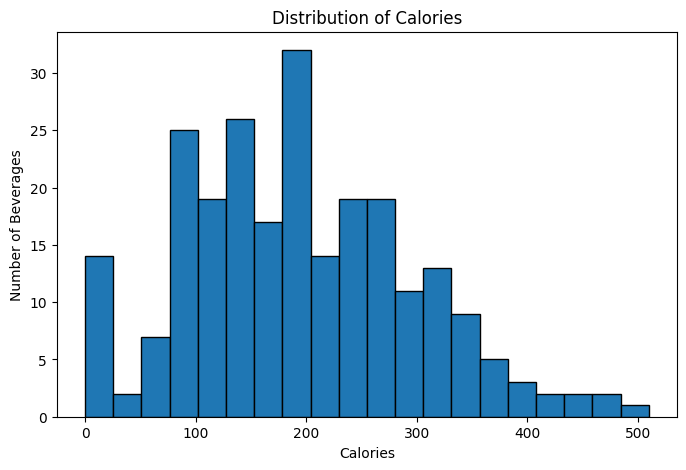

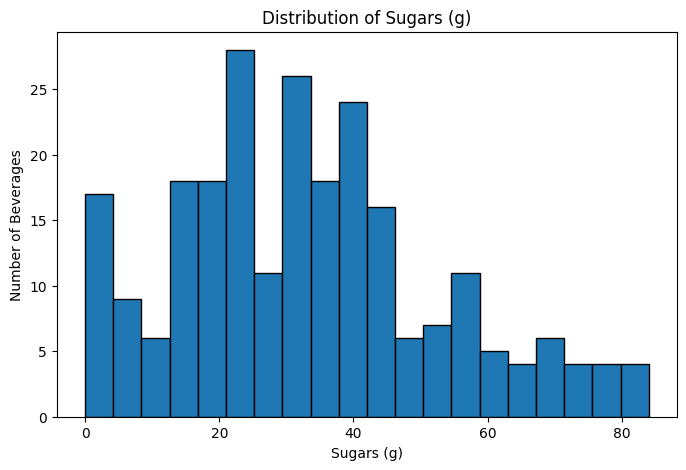

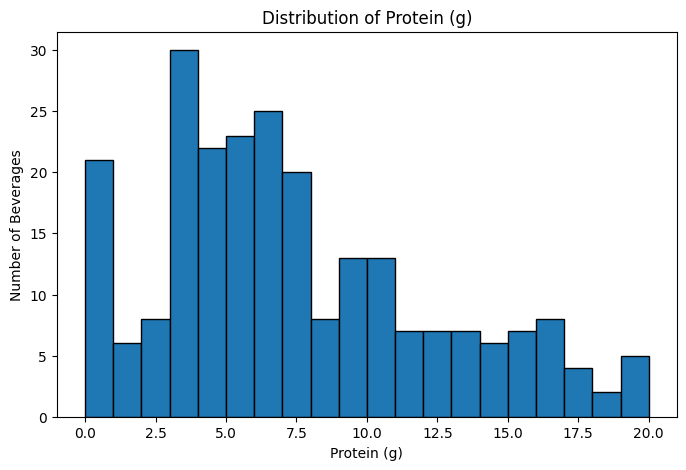

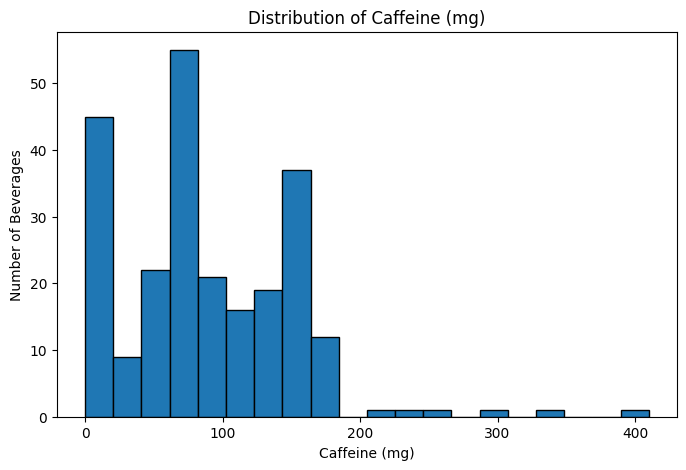

In [21]:
features = [
    'Calories',
    'Sugars (g)',
    'Protein (g)',
    'Caffeine (mg)'
]

for feature in features:
    plt.figure(figsize=(8, 5))
    plt.hist(df[feature], bins=20, edgecolor='black')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Number of Beverages')
    plt.show()

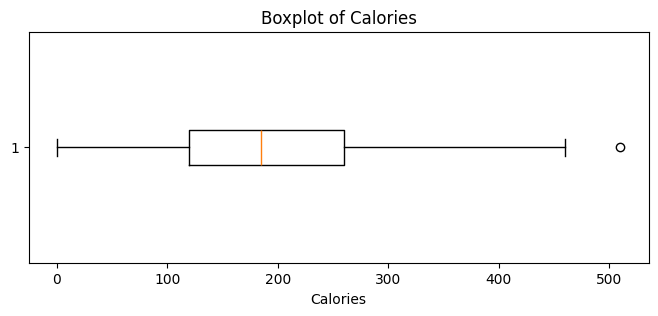

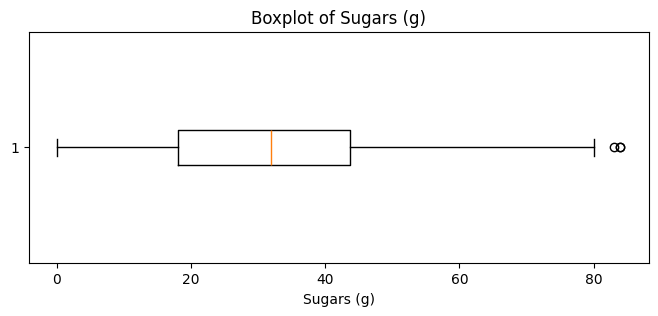

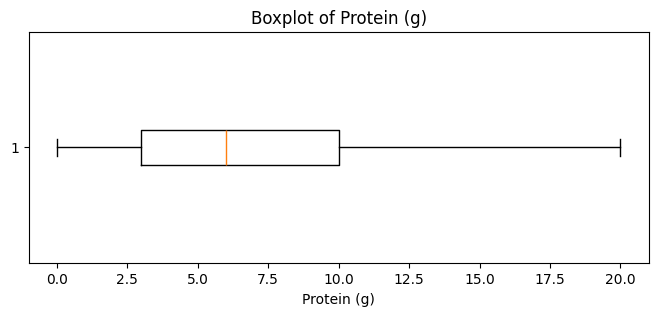

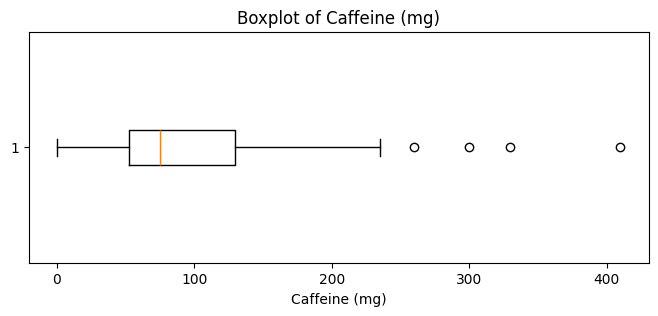

In [22]:
for feature in features:
    plt.figure(figsize=(8, 3))
    plt.boxplot(df[feature], vert=False)
    plt.title(f'Boxplot of {feature}')
    plt.xlabel(feature)
    plt.show()

In [23]:
category_nutrition = (
    df.groupby('Beverage_category')[
        ['Calories', 'Sugars (g)', 'Protein (g)', 'Caffeine (mg)']
    ]
    .mean()
    .round(2)
    .sort_values('Calories', ascending=False)
)

category_nutrition

,Calories,Sugars (g),Protein (g),Caffeine (mg)
Beverage_category,,,,
Smoothies,282.22,36.78,17.11,5.00
Frappuccino® Blended Coffee,276.94,57.08,4.22,101.81
Signature Espresso Drinks,250.00,38.60,9.88,73.88
Frappuccino® Blended Crème,233.08,48.46,4.00,0.00
Tazo® Tea Drinks,177.31,30.31,6.81,51.06
Frappuccino® Light Blended Coffee,162.50,32.42,4.25,99.58
Classic Espresso Drinks,140.17,16.97,8.69,122.07
Shaken Iced Beverages,114.44,26.00,1.34,134.72
Coffee,4.25,0.00,0.70,293.75


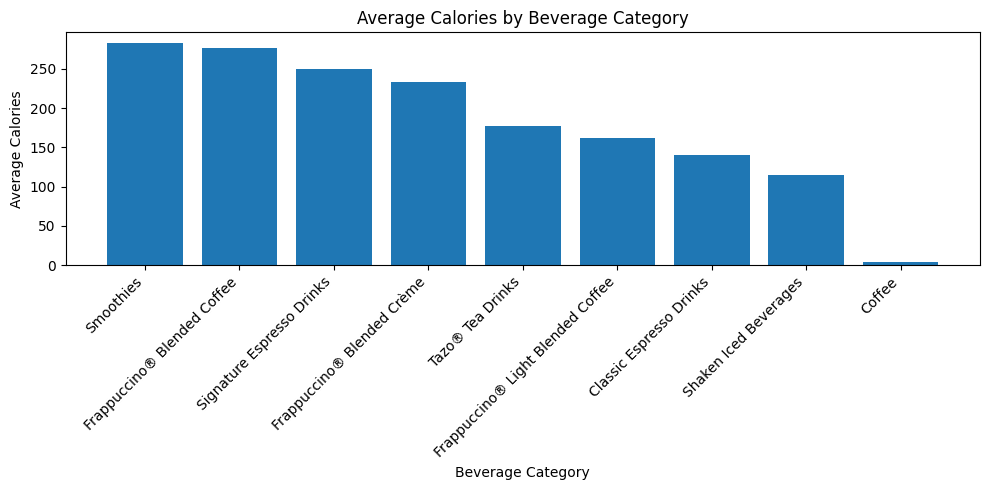

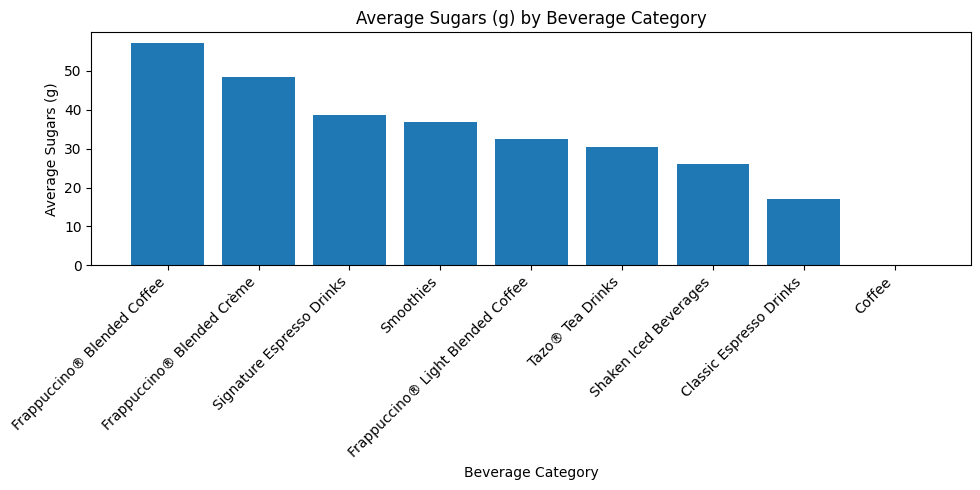

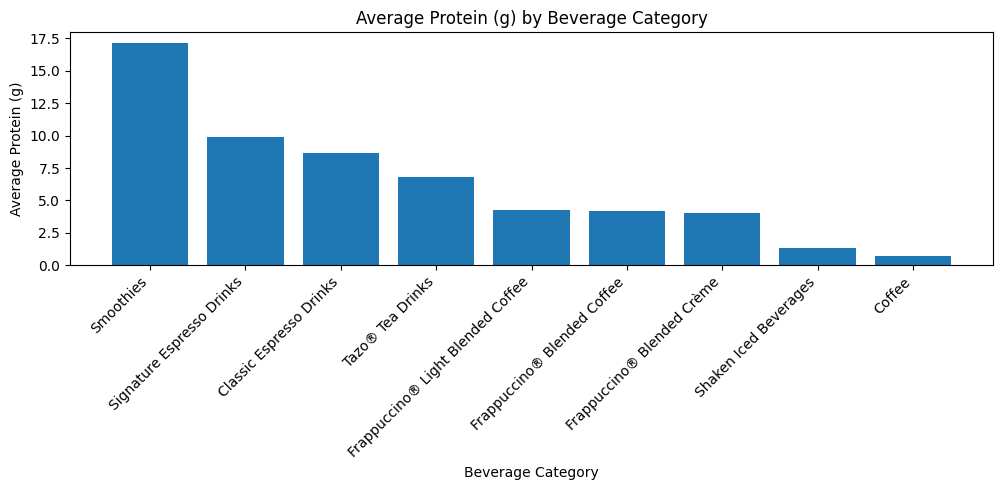

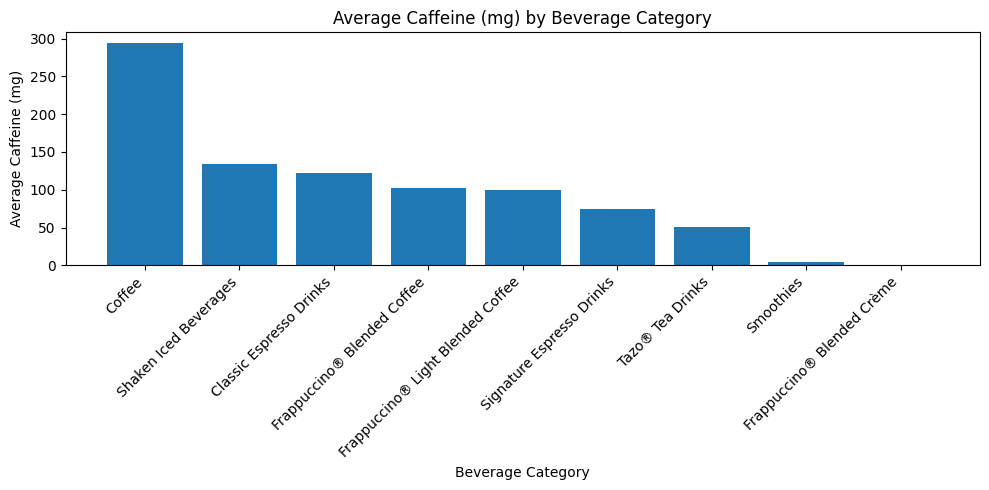

In [24]:
metrics = [
    'Calories',
    'Sugars (g)',
    'Protein (g)',
    'Caffeine (mg)'
]

for metric in metrics:
    category_values = (
        df.groupby('Beverage_category')[metric]
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(10, 5))
    plt.bar(category_values.index, category_values.values)
    plt.title(f'Average {metric} by Beverage Category')
    plt.xlabel('Beverage Category')
    plt.ylabel(f'Average {metric}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [25]:
correlation_features = [
    'Calories',
    'Total Fat (g)',
    'Total Carbohydrates (g)',
    'Sugars (g)',
    'Protein (g)',
    'Caffeine (mg)'
]

correlation_matrix = df[correlation_features].corr()

correlation_matrix.round(2)

,Calories,Total Fat (g),Total Carbohydrates (g),Sugars (g),Protein (g),Caffeine (mg)
Calories,1.00,0.63,0.80,0.91,0.58,-0.03
Total Fat (g),0.63,1.00,0.45,0.33,0.55,0.11
Total Carbohydrates (g),0.80,0.45,1.00,0.77,0.41,0.08
Sugars (g),0.91,0.33,0.77,1.00,0.26,-0.07
Protein (g),0.58,0.55,0.41,0.26,1.00,0.01
Caffeine (mg),-0.03,0.11,0.08,-0.07,0.01,1.00


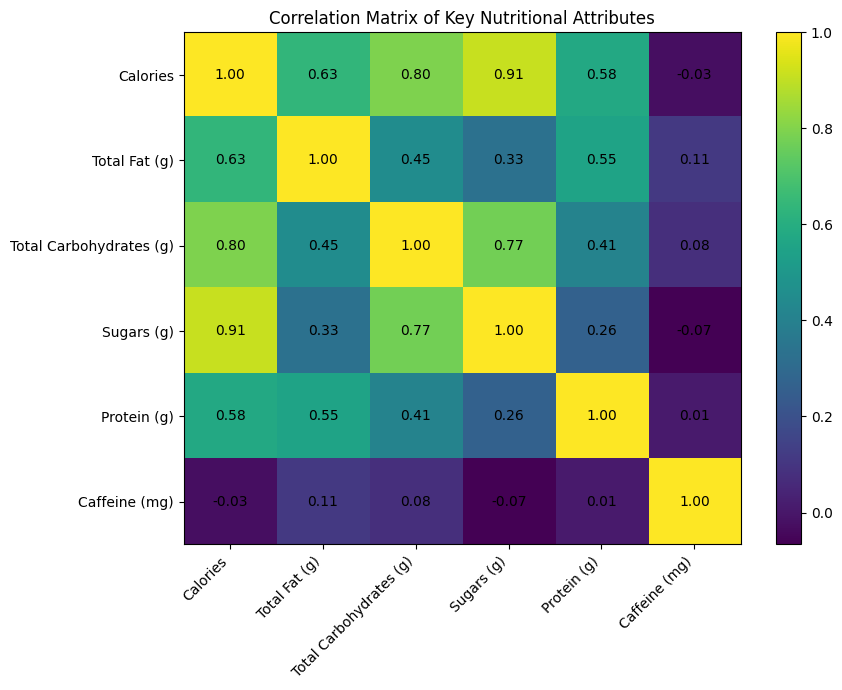

In [26]:
plt.figure(figsize=(9, 7))

plt.imshow(correlation_matrix, aspect='auto')
plt.colorbar()

plt.xticks(
    range(len(correlation_features)),
    correlation_features,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(len(correlation_features)),
    correlation_features
)

for i in range(len(correlation_features)):
    for j in range(len(correlation_features)):
        plt.text(
            j, i,
            f'{correlation_matrix.iloc[i, j]:.2f}',
            ha='center',
            va='center'
        )

plt.title('Correlation Matrix of Key Nutritional Attributes')
plt.tight_layout()
plt.show()

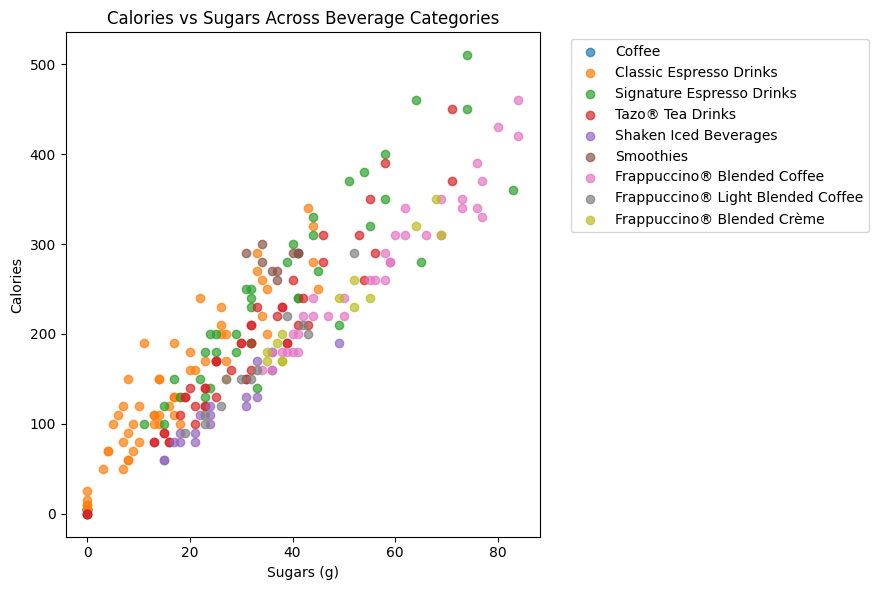

In [27]:
plt.figure(figsize=(9, 6))

for category in df['Beverage_category'].unique():
    subset = df[df['Beverage_category'] == category]

    plt.scatter(
        subset['Sugars (g)'],
        subset['Calories'],
        label=category,
        alpha=0.7
    )

plt.title('Calories vs Sugars Across Beverage Categories')
plt.xlabel('Sugars (g)')
plt.ylabel('Calories')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

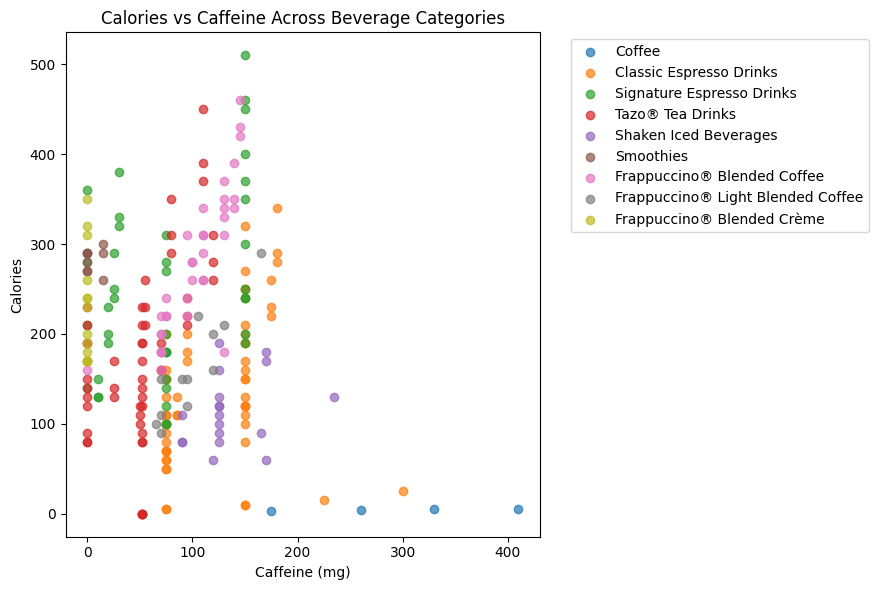

In [28]:
plt.figure(figsize=(9, 6))

for category in df['Beverage_category'].unique():
    subset = df[df['Beverage_category'] == category]

    plt.scatter(
        subset['Caffeine (mg)'],
        subset['Calories'],
        label=category,
        alpha=0.7
    )

plt.title('Calories vs Caffeine Across Beverage Categories')
plt.xlabel('Caffeine (mg)')
plt.ylabel('Calories')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [30]:
# Features selected for K-Means clustering
clustering_features = [
    'Calories',
    'Total Fat (g)',
    'Total Carbohydrates (g)',
    'Sugars (g)',
    'Protein (g)',
    'Caffeine (mg)'
]

X = df[clustering_features]

X.head()

,Calories,Total Fat (g),Total Carbohydrates (g),Sugars (g),Protein (g),Caffeine (mg)
0,3,0.1,5,0,0.3,175.0
1,4,0.1,10,0,0.5,260.0
2,5,0.1,10,0,1.0,330.0
3,5,0.1,10,0,1.0,410.0
4,70,0.1,75,9,6.0,75.0


In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-1.85943369, -0.95225359, -1.50833768, -1.67414054, -1.37373195,
         1.39528821],
       [-1.8496919 , -0.95225359, -1.44746081, -1.67414054, -1.33259309,
         2.75199246],
       [-1.83995011, -0.95225359, -1.44746081, -1.67414054, -1.22974594,
         3.86927831],
       [-1.83995011, -0.95225359, -1.44746081, -1.67414054, -1.22974594,
         5.14617642],
       [-1.20673386, -0.95225359, -0.65606148, -1.21704162, -0.20127443,
        -0.20083444]])

In [32]:
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=clustering_features
)

X_scaled_df.describe().round(2)

,Calories,Total Fat (g),Total Carbohydrates (g),Sugars (g),Protein (g),Caffeine (mg)
count,242.00,241.00,242.00,242.00,242.00,242.00
mean,0.00,0.00,-0.00,-0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.89,-0.99,-1.57,-1.67,-1.44,-1.40
25%,-0.72,-0.92,-0.72,-0.76,-0.82,-0.56
50%,-0.09,-0.14,-0.05,-0.05,-0.20,-0.20
75%,0.64,0.54,0.50,0.55,0.62,0.68
max,3.08,4.11,2.57,2.59,2.68,5.15


In [33]:
df[df['Total Fat (g)'].isnull()]

,Beverage_category,Beverage,Beverage_prep,Calories,Total Fat (g),Trans Fat (g),Saturated Fat (g),Sodium (mg),Total Carbohydrates (g),Cholesterol (mg),Dietary Fibre (g),Sugars (g),Protein (g),Vitamin A (% DV),Vitamin C (% DV),Calcium (% DV),Iron (% DV),Caffeine (mg)
237,Frappuccino® Blended Crème,Strawberries & Crème (Without Whipped Cream),Soymilk,320,NaN,0.4,0.0,0,250,67,1,64,5.0,6.0,8.0,20.0,10.0,0.0


In [34]:
df['Total Fat (g)'] = df['Total Fat (g)'].fillna(
    df.groupby('Beverage_category')['Total Fat (g)'].transform('median')
)

In [35]:
print(df['Total Fat (g)'].isnull().sum())

0


In [36]:
X = df[clustering_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=clustering_features
)

X_scaled_df.describe().round(2)

,Calories,Total Fat (g),Total Carbohydrates (g),Sugars (g),Protein (g),Caffeine (mg)
count,242.00,242.00,242.00,242.00,242.00,242.00
mean,0.00,0.00,-0.00,-0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.89,-0.99,-1.57,-1.67,-1.44,-1.40
25%,-0.72,-0.92,-0.72,-0.76,-0.82,-0.56
50%,-0.09,-0.22,-0.05,-0.05,-0.20,-0.20
75%,0.64,0.54,0.50,0.55,0.62,0.68
max,3.08,4.12,2.57,2.59,2.68,5.15


In [37]:
wcss = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

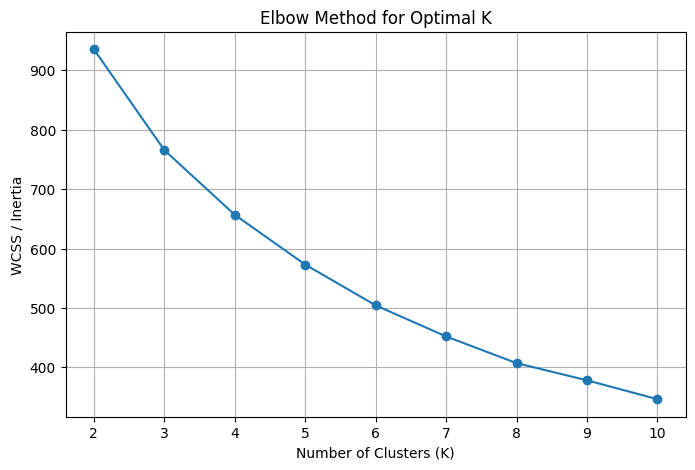

In [38]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, wcss, marker='o')

plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS / Inertia')
plt.xticks(k_values)
plt.grid()
plt.show()

In [39]:
### 5.3 K-Means Model Training

##Based on the Elbow Method, **K = 5** was selected as the optimal number of clusters. The final K-Means model groups Starbucks beverages into five segments based on their nutritional characteristics.

In [40]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X_scaled)

df[['Beverage', 'Beverage_category', 'Calories', 'Sugars (g)',
    'Protein (g)', 'Caffeine (mg)', 'Cluster']].head(10)

,Beverage,Beverage_category,Calories,Sugars (g),Protein (g),Caffeine (mg),Cluster
0,Brewed Coffee,Coffee,3,0,0.3,175.0,3
1,Brewed Coffee,Coffee,4,0,0.5,260.0,3
2,Brewed Coffee,Coffee,5,0,1.0,330.0,3
3,Brewed Coffee,Coffee,5,0,1.0,410.0,3
4,Caffè Latte,Classic Espresso Drinks,70,9,6.0,75.0,1
5,Caffè Latte,Classic Espresso Drinks,100,9,6.0,75.0,1
6,Caffè Latte,Classic Espresso Drinks,70,4,5.0,75.0,1
7,Caffè Latte,Classic Espresso Drinks,100,14,10.0,75.0,1
8,Caffè Latte,Classic Espresso Drinks,150,14,10.0,75.0,2
9,Caffè Latte,Classic Espresso Drinks,110,6,8.0,75.0,1


In [41]:
cluster_counts = df['Cluster'].value_counts().sort_index()

print(cluster_counts)

Cluster
0    47
1    78
2    58
3    34
4    25
Name: count, dtype: int64


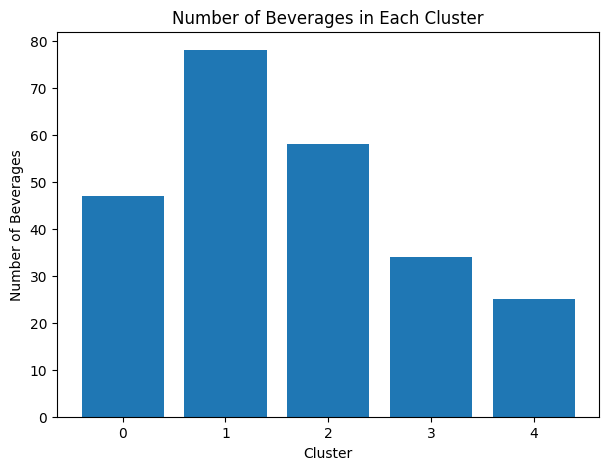

In [42]:
plt.figure(figsize=(7, 5))

plt.bar(
    cluster_counts.index.astype(str),
    cluster_counts.values
)

plt.title('Number of Beverages in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Beverages')

plt.show()

In [43]:
cluster_profile = (
    df.groupby('Cluster')[clustering_features]
    .mean()
    .round(2)
)

cluster_profile

,Calories,Total Fat (g),Total Carbohydrates (g),Sugars (g),Protein (g),Caffeine (mg)
Cluster,,,,,,
0,220.00,1.45,180.00,46.34,3.83,60.74
1,130.13,2.18,85.13,19.88,6.22,59.90
2,253.62,5.10,148.28,35.33,12.83,93.58
3,66.97,0.31,15.88,14.15,1.26,147.35
4,377.60,6.26,278.00,68.72,9.48,129.20


In [44]:
cluster_profile['Number of Beverages'] = df.groupby('Cluster').size()

cluster_profile

,Calories,Total Fat (g),Total Carbohydrates (g),Sugars (g),Protein (g),Caffeine (mg),Number of Beverages
Cluster,,,,,,,
0,220.00,1.45,180.00,46.34,3.83,60.74,47
1,130.13,2.18,85.13,19.88,6.22,59.90,78
2,253.62,5.10,148.28,35.33,12.83,93.58,58
3,66.97,0.31,15.88,14.15,1.26,147.35,34
4,377.60,6.26,278.00,68.72,9.48,129.20,25


In [45]:
cluster_names = {
    0: 'High Sugar',
    1: 'Moderate Nutrition',
    2: 'High Protein',
    3: 'Low Calorie High Caffeine',
    4: 'Indulgent High Calorie'
}

df['Cluster_Name'] = df['Cluster'].map(cluster_names)

df[['Beverage', 'Beverage_category', 'Cluster', 'Cluster_Name']].head(10)

,Beverage,Beverage_category,Cluster,Cluster_Name
0,Brewed Coffee,Coffee,3,Low Calorie High Caffeine
1,Brewed Coffee,Coffee,3,Low Calorie High Caffeine
2,Brewed Coffee,Coffee,3,Low Calorie High Caffeine
3,Brewed Coffee,Coffee,3,Low Calorie High Caffeine
4,Caffè Latte,Classic Espresso Drinks,1,Moderate Nutrition
5,Caffè Latte,Classic Espresso Drinks,1,Moderate Nutrition
6,Caffè Latte,Classic Espresso Drinks,1,Moderate Nutrition
7,Caffè Latte,Classic Espresso Drinks,1,Moderate Nutrition
8,Caffè Latte,Classic Espresso Drinks,2,High Protein
9,Caffè Latte,Classic Espresso Drinks,1,Moderate Nutrition


In [46]:
final_cluster_profile = (
    df.groupby(['Cluster', 'Cluster_Name'])[clustering_features]
    .mean()
    .round(2)
)

final_cluster_profile['Number of Beverages'] = (
    df.groupby(['Cluster', 'Cluster_Name'])
    .size()
)

final_cluster_profile

,,Calories,Total Fat (g),Total Carbohydrates (g),Sugars (g),Protein (g),Caffeine (mg),Number of Beverages
Cluster,Cluster_Name,,,,,,,
0,High Sugar,220.00,1.45,180.00,46.34,3.83,60.74,47
1,Moderate Nutrition,130.13,2.18,85.13,19.88,6.22,59.90,78
2,High Protein,253.62,5.10,148.28,35.33,12.83,93.58,58
3,Low Calorie High Caffeine,66.97,0.31,15.88,14.15,1.26,147.35,34
4,Indulgent High Calorie,377.60,6.26,278.00,68.72,9.48,129.20,25


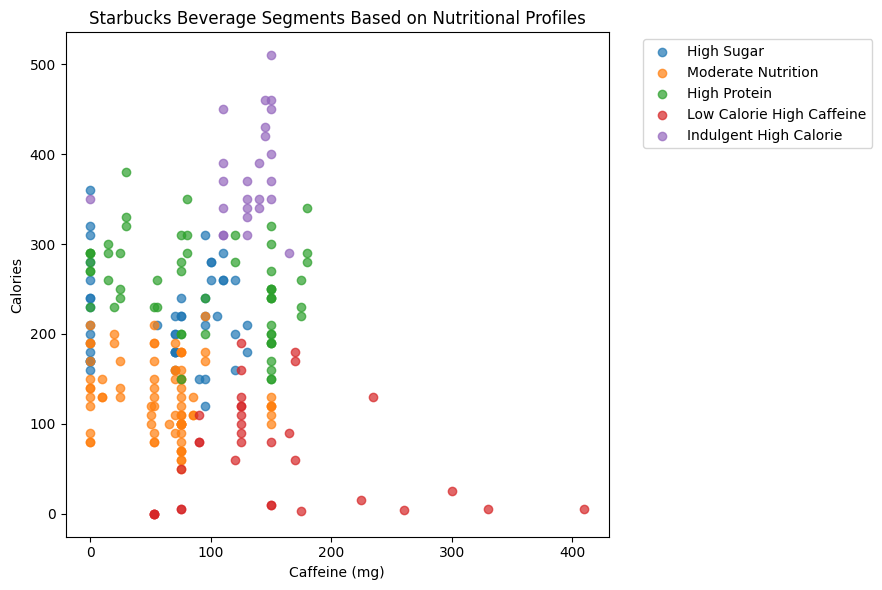

In [47]:
plt.figure(figsize=(9, 6))

for cluster in sorted(df['Cluster'].unique()):
    subset = df[df['Cluster'] == cluster]

    plt.scatter(
        subset['Caffeine (mg)'],
        subset['Calories'],
        label=cluster_names[cluster],
        alpha=0.7
    )

plt.title('Starbucks Beverage Segments Based on Nutritional Profiles')
plt.xlabel('Caffeine (mg)')
plt.ylabel('Calories')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [48]:
for cluster in sorted(df['Cluster'].unique()):

    print(f"\n{'='*60}")
    print(f"CLUSTER {cluster}: {cluster_names[cluster]}")
    print('='*60)

    display(
        df[df['Cluster'] == cluster][
            [
                'Beverage',
                'Beverage_category',
                'Beverage_prep',
                'Calories',
                'Sugars (g)',
                'Protein (g)',
                'Caffeine (mg)'
            ]
        ].head(5)
    )


CLUSTER 0: High Sugar


,Beverage,Beverage_category,Beverage_prep,Calories,Sugars (g),Protein (g),Caffeine (mg)
99,Caramel Apple Spice (Without Whipped Cream),Signature Espresso Drinks,Tall,210,49,0.0,0.0
100,Caramel Apple Spice (Without Whipped Cream),Signature Espresso Drinks,Grande,280,65,0.0,0.0
101,Caramel Apple Spice (Without Whipped Cream),Signature Espresso Drinks,Venti,360,83,0.0,0.0
112,Tazo® Chai Tea Latte,Tazo® Tea Drinks,Grande Nonfat Milk,210,43,8.0,95.0
115,Tazo® Chai Tea Latte,Tazo® Tea Drinks,Venti Nonfat Milk,260,54,10.0,120.0



CLUSTER 1: Moderate Nutrition


,Beverage,Beverage_category,Beverage_prep,Calories,Sugars (g),Protein (g),Caffeine (mg)
4,Caffè Latte,Classic Espresso Drinks,Short Nonfat Milk,70,9,6.0,75.0
5,Caffè Latte,Classic Espresso Drinks,2% Milk,100,9,6.0,75.0
6,Caffè Latte,Classic Espresso Drinks,Soymilk,70,4,5.0,75.0
7,Caffè Latte,Classic Espresso Drinks,Tall Nonfat Milk,100,14,10.0,75.0
9,Caffè Latte,Classic Espresso Drinks,Soymilk,110,6,8.0,75.0



CLUSTER 2: High Protein


,Beverage,Beverage_category,Beverage_prep,Calories,Sugars (g),Protein (g),Caffeine (mg)
8,Caffè Latte,Classic Espresso Drinks,2% Milk,150,14,10.0,75.0
11,Caffè Latte,Classic Espresso Drinks,2% Milk,190,17,12.0,150.0
12,Caffè Latte,Classic Espresso Drinks,Soymilk,150,8,10.0,150.0
13,Caffè Latte,Classic Espresso Drinks,Venti Nonfat Milk,170,23,16.0,150.0
14,Caffè Latte,Classic Espresso Drinks,2% Milk,240,22,16.0,150.0



CLUSTER 3: Low Calorie High Caffeine


,Beverage,Beverage_category,Beverage_prep,Calories,Sugars (g),Protein (g),Caffeine (mg)
0,Brewed Coffee,Coffee,Short,3,0,0.3,175.0
1,Brewed Coffee,Coffee,Tall,4,0,0.5,260.0
2,Brewed Coffee,Coffee,Grande,5,0,1.0,330.0
3,Brewed Coffee,Coffee,Venti,5,0,1.0,410.0
40,Caffè Americano,Classic Espresso Drinks,Short,5,0,0.4,75.0



CLUSTER 4: Indulgent High Calorie


,Beverage,Beverage_category,Beverage_prep,Calories,Sugars (g),Protein (g),Caffeine (mg)
80,White Chocolate Mocha (Without Whipped Cream),Signature Espresso Drinks,Grande Nonfat Milk,350,58,15.0,150.0
81,White Chocolate Mocha (Without Whipped Cream),Signature Espresso Drinks,2% Milk,400,58,15.0,150.0
82,White Chocolate Mocha (Without Whipped Cream),Signature Espresso Drinks,Soymilk,370,51,13.0,150.0
83,White Chocolate Mocha (Without Whipped Cream),Signature Espresso Drinks,Venti Nonfat Milk,450,74,19.0,150.0
84,White Chocolate Mocha (Without Whipped Cream),Signature Espresso Drinks,2% Milk,510,74,19.0,150.0
